# **Tugas 2**
Pemerolehan Informasi dan Penambangan Teks

## **Objective**
**Parsing & Preprocessing:**
- Parsing dokumen dari corpus.txt (`<DOC>, <TITLE>, <TEXT>`)
- Cleaning teks (lowercase, hapus non-alfabet, hapus stopwords, tokenisasi)
<br>

**Menjawab soal:**
1. Berapa banyak dokumen yang ada di dalam korpus?
2. Tuliskan 20 kata yang frekuensinya paling tinggi pada koleksi tersebut beserta frekuensinya dan urutkan berdasarkan frekuensi (bukan alfabet).
3. Tuliskan 20 kata yang muncul di seluruh dokumen.
4. Tuliskan 10 kata yang hanya muncul di 50 dokumen.
5. Apakah kata-kata pada koleksi dokumen ini mengikuti distribusi Zipf? Gambarkan juga grafiknya menggunakan matplotlib atau Excel.
6. Berapa banyak kata yang frekuensinya kurang dari 10 pada koleksi ini?
7. Berapa banyak seluruh kata pada koleksi ini?
8. Berapa banyak kata-kata yang unik dalam koleksi ini?
9. Berapa banyak kata unik yang berawalan/berimbuhan "ber-" (contoh "beranda" tidak termasuk, tetapi "berubah" termasuk)?
10. Berapa banyak kata unik yang berakhiran/berimbuhan "-kan" (contoh "makan" tidak termasuk, tetapi "dibuatkan" termasuk)?
11. Berapa banyak kalimat dalam korpus dan bagaimana cara melakukan segmentasi kalimat dalam program?
12. Berapa frekuensi frase (top 20) yang terdiri dari 2 (bigram) dan 3 (trigram) kata pada koleksi ini?

In [1]:
import re

## **Preprocessing & Parsing**

Definisikan fungsi

In [2]:
def preprocess_text(text, stopwords=None):
    # lowercase
    text = text.lower()
    # hapus non-alfabet
    text = re.sub(r'[^a-z\s]', ' ', text)
    # tokenisasi (whitespaces)
    tokens = text.split()
    # hapus stopwords
    if stopwords is not None:
        tokens = [word for word in tokens if word not in stopwords]
    
    return tokens

In [3]:
def load_stopwords(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        stopwords = set(line.strip().lower() for line in f)
    return stopwords

In [4]:
def preprocess_corpus(file_path, stopwords_path=None):
    stopwords = load_stopwords(stopwords_path) if stopwords_path else None
    
    with open(file_path, 'r', encoding='utf-8') as f:
        content = f.read()
    
    docs = re.findall(r'<DOC>(.*?)</DOC>', content, re.DOTALL)
    processed_docs = []
    
    for doc in docs:
        title = re.search(r'<TITLE>(.*?)</TITLE>', doc, re.DOTALL)
        text = re.search(r'<TEXT>(.*?)</TEXT>', doc, re.DOTALL)
        title = title.group(1) if title else ""
        text = text.group(1) if text else ""
        full_text = title + " " + text
        tokens = preprocess_text(full_text, stopwords)
        processed_docs.append(tokens)
    
    return processed_docs

Lakukan preprocess

In [5]:
corpus = preprocess_corpus(
    "../../data/tugas2/corpus.txt",
    "../../data/tugas2/id.stopwords.02.01.2016.txt"
)

Cek hasil preprocess

In [6]:
print(corpus[0][:100])

['cepat', 'turunkan', 'kadar', 'gula', 'darah', 'kadargula', 'darah', 'melonjak', 'ditangani', 'berkembang', 'kondisi', 'berbahaya', 'penderita', 'diabetes', 'lonjakan', 'gula', 'darah', 'hiperglikemia', 'pasien', 'diabetes', 'kondisi', 'berisiko', 'memicu', 'komplikasi', 'serius', 'dibiarkan', 'advertisement', 'scroll', 'to', 'continue', 'with', 'content', 'dokter', 'spesialis', 'endokrinologi', 'beatrice', 'hong', 'jangka', 'pendek', 'kadar', 'gula', 'berkembang', 'kondisi', 'gawat', 'darurat', 'ketoasidosis', 'diabetik', 'sindrom', 'hiperglikemik', 'hiperosmolar', 'jangka', 'kadar', 'gula', 'darah', 'mengalami', 'komplikasi', 'jangka', 'diabetes', 'penyakit', 'sistemik', 'berisiko', 'mengalami', 'mata', 'ginjal', 'saraf', 'kaki', 'jantung', 'hong', 'melansir', 'prevention', 'menurunkan', 'gula', 'darah', 'cepat', 'aman', 'penderita', 'diabetes', 'insulin', 'langkah', 'dosis', 'terlewat', 'alat', 'pompa', 'insulin', 'berfungsi', 'insulin', 'hormon', 'diproduksi', 'pankreas', 'berfung

## **Menjawab Soal**

### **1. Berapa banyak dokumen yang ada di dalam korpus?**

In [7]:
jumlah_dokumen = len(corpus)
print("Jumlah dokumen:", jumlah_dokumen)

Jumlah dokumen: 479


### **2.Tuliskan 20 kata yang frekuensinya paling tinggi pada koleksi tersebut beserta frekuensinya dan urutkan berdasarkan frekuensi (bukan alfabet).**

In [8]:
# flaten semua token
all_words = [word for doc in corpus for word in doc]

In [9]:
# hitung semua frekuensi
from collections import Counter

word_freq = Counter(all_words)

In [10]:
# top 20 frekuensi tertinggi
print("Top 20 kata dengan frekuensi tertinggi:\n")
top_20 = word_freq.most_common(20)

for word, freq in top_20:
    print(f"{word}: {freq}")

Top 20 kata dengan frekuensi tertinggi:

indonesia: 571
harga: 413
iran: 360
negara: 339
orang: 334
rp: 331
to: 272
scroll: 260
with: 260
continue: 258
content: 258
memiliki: 254
kompas: 247
salah: 238
pemain: 237
dunia: 236
persen: 233
anak: 230
minyak: 220
as: 212


### **3. Tuliskan 20 kata yang muncul di seluruh dokumen.**


#### Stopwords dihapus

In [11]:
# intersection semua dokumen
common_words = set(corpus[0])

for doc in corpus[1:]:
    common_words &= set(doc)

In [12]:
# ambil 20 kata
print("Jumlah kata yang muncul di semua dokumen:", len(common_words))
common_20 = list(common_words)[:20]

for i, word in enumerate(common_20, 1):
    print(f"{i}. {word}")

Jumlah kata yang muncul di semua dokumen: 0


In [13]:
from collections import Counter

doc_freq = Counter()

for doc in corpus:
    for word in set(doc):
        doc_freq[word] += 1

print("Jumlah dokumen:", len(corpus))
print("Top kata dengan document frequency tertinggi:")
print(doc_freq.most_common(10))

Jumlah dokumen: 479
Top kata dengan document frequency tertinggi:
[('to', 260), ('scroll', 259), ('with', 259), ('continue', 258), ('content', 258), ('indonesia', 190), ('advertisement', 167), ('memiliki', 167), ('salah', 164), ('kompas', 130)]


#### Stopwords tidak dihapus

In [14]:
corpus_3 = preprocess_corpus(
    "../../data/tugas2/corpus.txt",
)

In [15]:
# intersection semua dokumen
common_words = set(corpus_3[0])

for doc in corpus_3[1:]:
    common_words &= set(doc)

In [16]:
# ambil 20 kata
print("Jumlah kata yang muncul di semua dokumen:", len(common_words))
common_20 = list(common_words)[:20]

for i, word in enumerate(common_20, 1):
    print(f"{i}. {word}")

Jumlah kata yang muncul di semua dokumen: 0


In [19]:
from collections import Counter

doc_freq = Counter()

for doc in corpus_3:
    for word in set(doc):
        doc_freq[word] += 1

print("Jumlah dokumen:", len(corpus_3))
print("Top kata dengan document frequency tertinggi:")
print(doc_freq.most_common(10))

Jumlah dokumen: 479
Top kata dengan document frequency tertinggi:
[('di', 460), ('dan', 458), ('yang', 456), ('dengan', 417), ('ini', 404), ('dari', 400), ('dalam', 397), ('untuk', 390), ('pada', 384), ('juga', 358)]


### **4. Tuliskan 10 kata yang hanya muncul di 50 dokumen.**

In [20]:
# document frequency
from collections import Counter

doc_freq = Counter()

for doc in corpus:
    for word in set(doc):   
        doc_freq[word] += 1

In [25]:
# ambil kata yang muncul di 50 doc
kata_50 = [word for word, count in doc_freq.items() if count == 50]
print("Jumlah kata dengan DF 50 = ", len(kata_50))

Jumlah kata dengan DF 50 =  6


In [26]:
# ambil 10 kata 
print("\n10 kata yang muncul tepat di 50 dokumen:\n")

if len(kata_50) == 0:
    print("Tidak ada kata yang muncul tepat di 50 dokumen.")
else:
    for i, word in enumerate(kata_50[:10], 1):
        print(f"{i}. {word}")


10 kata yang muncul tepat di 50 dokumen:

1. cnn
2. ya
3. gramedia
4. reserved
5. copyright
6. rights


### **5. Apakah kata-kata pada koleksi dokumen ini mengikuti distribusi Zipf? Gambarkan juga grafiknya menggunakan matplotlib atau Excel.**

#### Stopword tidak dihapus

In [27]:
corpus_5 = preprocess_corpus(
    "../../data/tugas2/corpus.txt",
)

In [28]:
# flatten
all_words_zipf = [word for doc in corpus_5 for word in doc]

In [30]:
# menghitung frekuensi
from collections import Counter

word_freq_zipf = Counter(all_words_zipf)

# mengurutkan frekuensi
freqs = sorted(word_freq_zipf.values(), reverse=True)

In [31]:
# buat rank atau peringkat
ranks = range(1, len(freqs) + 1)

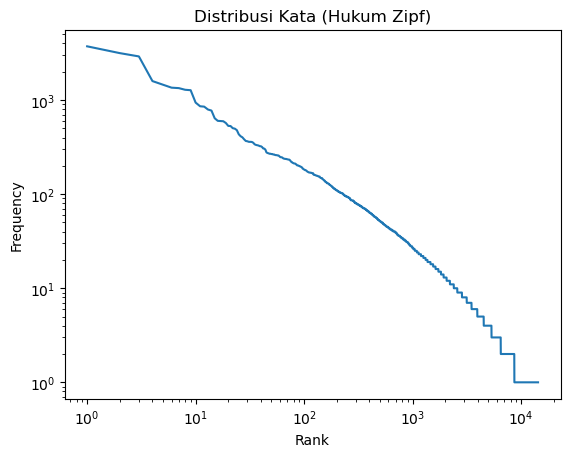

In [32]:
# plot zipf
import matplotlib.pyplot as plt

plt.figure()
plt.plot(ranks, freqs)

# log-log biar keliatan Zipf
plt.xscale('log')
plt.yscale('log')

plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Distribusi Kata (Hukum Zipf)")

plt.show()

### **6. Berapa banyak kata yang frekuensinya kurang dari 10 pada koleksi ini?**

In [39]:
# semua frekuensi
from collections import Counter

word_freq = Counter(all_words)
print("word freq", len(word_freq))

word freq 13788


In [37]:
# hitung frekuensi <10
kata_kurang_10 = [word for word, freq in word_freq.items() if freq < 10]

print("Jumlah kata dengan frekuensi < 10 = ", len(kata_kurang_10))

Jumlah kata dengan frekuensi < 10 =  11585


In [38]:
# lihat contoh 
print("\nContoh kata (maks 20):\n")

for i, word in enumerate(kata_kurang_10[:20], 1):
    print(f"{i}. {word} -> {word_freq[word]}")


Contoh kata (maks 20):

1. turunkan -> 3
2. kadargula -> 1
3. ditangani -> 6
4. hiperglikemia -> 3
5. dibiarkan -> 5
6. endokrinologi -> 3
7. beatrice -> 2
8. gawat -> 6
9. ketoasidosis -> 4
10. diabetik -> 2
11. sindrom -> 8
12. hiperglikemik -> 2
13. hiperosmolar -> 2
14. sistemik -> 5
15. saraf -> 6
16. prevention -> 2
17. dosis -> 8
18. terlewat -> 6
19. pompa -> 3
20. pankreas -> 3
